**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Generation**

In [2]:
np.random.seed(42)
n = 5000

data = pd.DataFrame({
    "customer_id": [f"CUST_{i:04d}" for i in range(1, n+1)],
    "age": np.random.randint(18, 76, n),
    "tenure_months": np.random.randint(1, 73, n),
    "contract_type": np.random.choice(
        ["Month-to-month","One year","Two year"],
        n,
        p=[0.5,0.3,0.2]
    ),
    "payment_method": np.random.choice(
        ["Electronic check","Mailed check","Bank transfer","Credit card"],
        n
    ),
    "online_security": np.random.choice(["Yes","No"], n),
    "tech_support": np.random.choice(["Yes","No"], n),
    "monthly_charges": np.round(np.random.uniform(20,150,n),2),
    "num_complaints": np.random.randint(0,11,n),
    "customer_service_calls": np.random.randint(0,16,n)
})

data["total_charges"] = (
    data["monthly_charges"] * data["tenure_months"]
    + np.random.normal(0,50,n)
)

data.head()

,customer_id,age,tenure_months,contract_type,payment_method,online_security,tech_support,monthly_charges,num_complaints,customer_service_calls,total_charges
0,CUST_0001,56,61,Month-to-month,Electronic check,No,No,80.81,9,5,4874.007272
1,CUST_0002,69,21,Month-to-month,Bank transfer,Yes,Yes,84.66,1,1,1713.115005
2,CUST_0003,46,46,One year,Credit card,Yes,Yes,76.81,5,4,3543.995352
3,CUST_0004,32,69,Month-to-month,Electronic check,Yes,Yes,71.08,1,5,4852.160250
4,CUST_0005,60,6,Month-to-month,Mailed check,No,Yes,84.96,8,4,574.195610


In [3]:
data


,customer_id,age,tenure_months,contract_type,payment_method,online_security,tech_support,monthly_charges,num_complaints,customer_service_calls,total_charges
0,CUST_0001,56,61,Month-to-month,Electronic check,No,No,80.81,9,5,4874.007272
1,CUST_0002,69,21,Month-to-month,Bank transfer,Yes,Yes,84.66,1,1,1713.115005
2,CUST_0003,46,46,One year,Credit card,Yes,Yes,76.81,5,4,3543.995352
3,CUST_0004,32,69,Month-to-month,Electronic check,Yes,Yes,71.08,1,5,4852.160250
4,CUST_0005,60,6,Month-to-month,Mailed check,No,Yes,84.96,8,4,574.195610
...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_4996,67,4,Month-to-month,Bank transfer,No,No,108.87,5,11,394.924952
4996,CUST_4997,55,46,Month-to-month,Mailed check,Yes,No,130.63,3,0,5989.789477
4997,CUST_4998,44,18,One year,Mailed check,Yes,Yes,144.70,3,15,2670.975535
4998,CUST_4999,51,43,Month-to-month,Electronic check,No,Yes,43.09,1,2,1794.386426


In [4]:
# Adding missing columns

data["gender"] = np.random.choice(["Male","Female","Other"], len(data))

data["internet_service"] = np.random.choice(
    ["DSL","Fiber optic","No"],
    len(data)
)

data["streaming_services"] = np.random.choice(
    ["Yes","No"],
    len(data)
)

data["phone_service"] = np.random.choice(
    ["Yes","No"],
    len(data)
)

data.head()

,customer_id,age,tenure_months,contract_type,payment_method,online_security,tech_support,monthly_charges,num_complaints,customer_service_calls,total_charges,gender,internet_service,streaming_services,phone_service
0,CUST_0001,56,61,Month-to-month,Electronic check,No,No,80.81,9,5,4874.007272,Female,No,No,Yes
1,CUST_0002,69,21,Month-to-month,Bank transfer,Yes,Yes,84.66,1,1,1713.115005,Female,DSL,Yes,Yes
2,CUST_0003,46,46,One year,Credit card,Yes,Yes,76.81,5,4,3543.995352,Male,DSL,Yes,Yes
3,CUST_0004,32,69,Month-to-month,Electronic check,Yes,Yes,71.08,1,5,4852.160250,Male,No,Yes,Yes
4,CUST_0005,60,6,Month-to-month,Mailed check,No,Yes,84.96,8,4,574.195610,Female,DSL,Yes,No


In [5]:
data


,customer_id,age,tenure_months,contract_type,payment_method,online_security,tech_support,monthly_charges,num_complaints,customer_service_calls,total_charges,gender,internet_service,streaming_services,phone_service
0,CUST_0001,56,61,Month-to-month,Electronic check,No,No,80.81,9,5,4874.007272,Female,No,No,Yes
1,CUST_0002,69,21,Month-to-month,Bank transfer,Yes,Yes,84.66,1,1,1713.115005,Female,DSL,Yes,Yes
2,CUST_0003,46,46,One year,Credit card,Yes,Yes,76.81,5,4,3543.995352,Male,DSL,Yes,Yes
3,CUST_0004,32,69,Month-to-month,Electronic check,Yes,Yes,71.08,1,5,4852.160250,Male,No,Yes,Yes
4,CUST_0005,60,6,Month-to-month,Mailed check,No,Yes,84.96,8,4,574.195610,Female,DSL,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_4996,67,4,Month-to-month,Bank transfer,No,No,108.87,5,11,394.924952,Male,Fiber optic,No,Yes
4996,CUST_4997,55,46,Month-to-month,Mailed check,Yes,No,130.63,3,0,5989.789477,Other,DSL,Yes,Yes
4997,CUST_4998,44,18,One year,Mailed check,Yes,Yes,144.70,3,15,2670.975535,Male,No,Yes,No
4998,CUST_4999,51,43,Month-to-month,Electronic check,No,Yes,43.09,1,2,1794.386426,Other,Fiber optic,No,Yes


**Creating the Churn Target Variable**

In [6]:
churn_prob = (
    (data["contract_type"] == "Month-to-month") * 0.40 +
    (data["payment_method"] == "Electronic check") * 0.20 +
    data["num_complaints"] * 0.04 +
    data["customer_service_calls"] * 0.03 -
    data["tenure_months"] * 0.006 +
    (data["tech_support"] == "No") * 0.15 +
    (data["online_security"] == "No") * 0.15
)

churn_prob = np.clip(churn_prob, 0, 1)

data["churn"] = np.where(np.random.rand(len(data)) < churn_prob, "Yes", "No")

data["churn"].value_counts(normalize=True)

,proportion
churn,
Yes,0.5982
No,0.4018


**EDA**

**Numerical Feature Distribution**

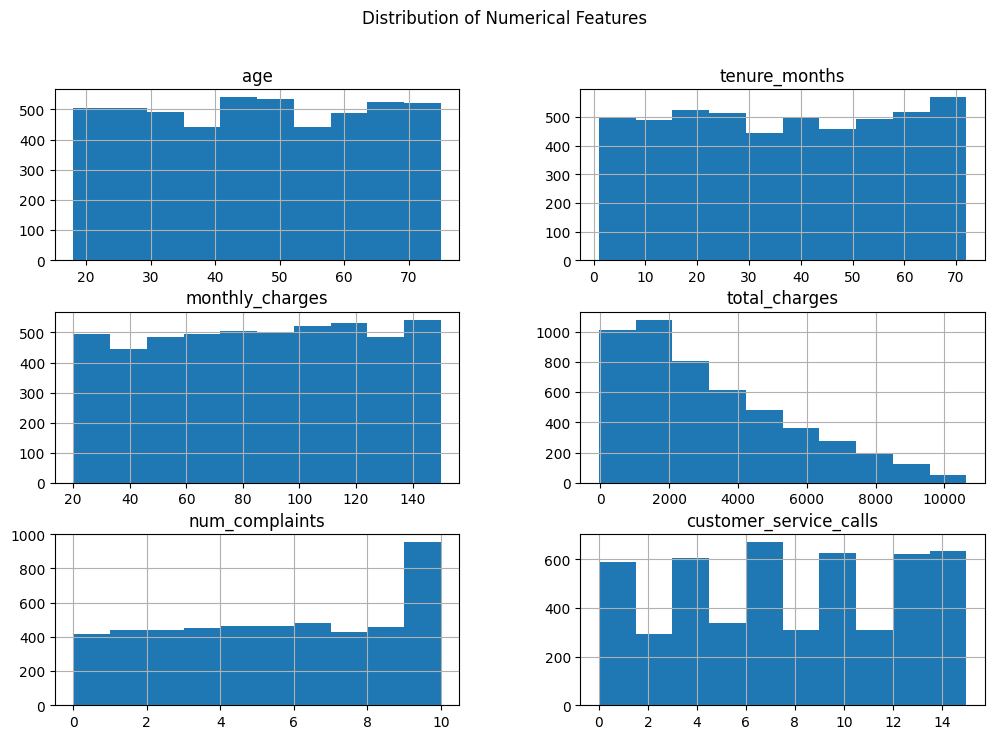

In [7]:
numeric_cols = ["age","tenure_months","monthly_charges",
                "total_charges","num_complaints",
                "customer_service_calls"]

data[numeric_cols].hist(figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

**Churn Rate by Contract Type**

In [8]:
pd.crosstab(data["contract_type"], data["churn"], normalize='index')

churn,No,Yes
contract_type,,
Month-to-month,0.227326,0.772674
One year,0.565718,0.434282
Two year,0.609007,0.390993


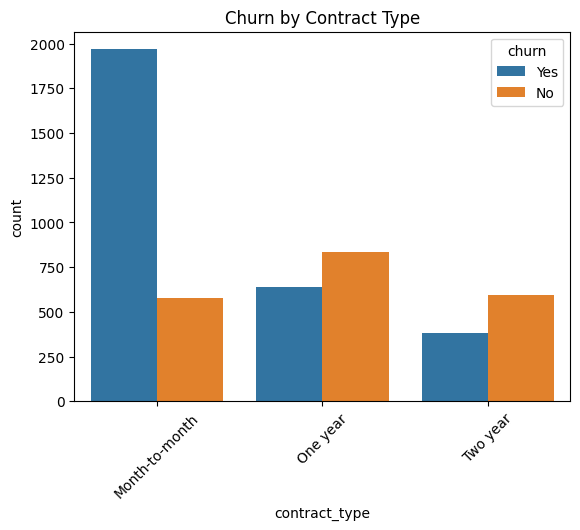

In [9]:
sns.countplot(x="contract_type", hue="churn", data=data)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

**Churn Rate by Payment Method**

In [10]:
pd.crosstab(data["payment_method"], data["churn"], normalize='index')

churn,No,Yes
payment_method,,
Bank transfer,0.439082,0.560918
Credit card,0.445432,0.554568
Electronic check,0.277325,0.722675
Mailed check,0.442262,0.557738


**Correlation Heatmap**

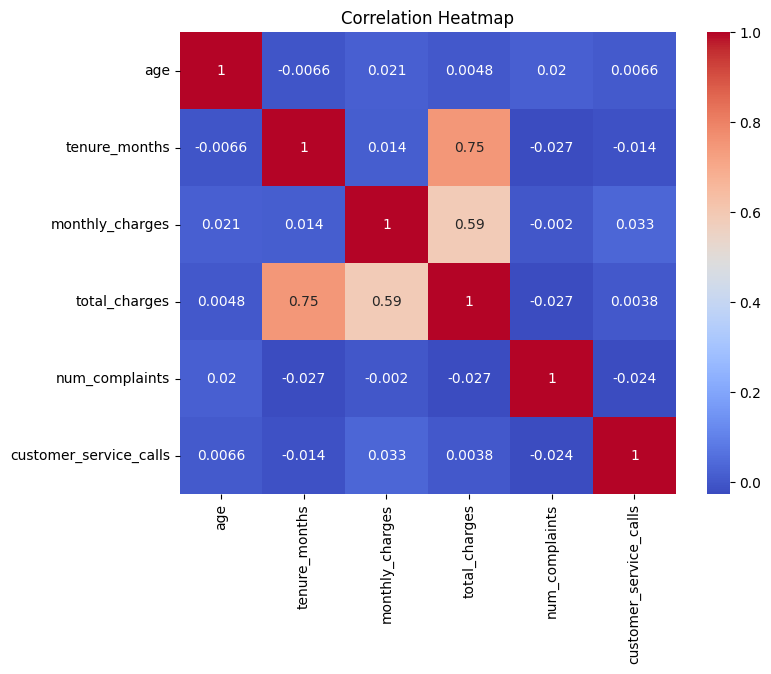

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Key Insights from EDA**

1.Customers with month-to-month contracts show a significantly higher churn rate compared to one-year and two-year contracts.

2.Customers with a higher number of complaints and customer service calls are more likely to churn.

3.Longer tenure is associated with lower churn probability, indicating that long-term customers are more stable.

4.Customers without tech support or online security services have higher churn rates.

5.Electronic check users demonstrate relatively higher churn compared to other payment methods

**Data Preprocessing**

In [12]:
data_model = data.drop("customer_id", axis=1)
data_model.head()

,age,tenure_months,contract_type,payment_method,online_security,tech_support,monthly_charges,num_complaints,customer_service_calls,total_charges,gender,internet_service,streaming_services,phone_service,churn
0,56,61,Month-to-month,Electronic check,No,No,80.81,9,5,4874.007272,Female,No,No,Yes,Yes
1,69,21,Month-to-month,Bank transfer,Yes,Yes,84.66,1,1,1713.115005,Female,DSL,Yes,Yes,No
2,46,46,One year,Credit card,Yes,Yes,76.81,5,4,3543.995352,Male,DSL,Yes,Yes,No
3,32,69,Month-to-month,Electronic check,Yes,Yes,71.08,1,5,4852.160250,Male,No,Yes,Yes,No
4,60,6,Month-to-month,Mailed check,No,Yes,84.96,8,4,574.195610,Female,DSL,Yes,No,Yes


In [13]:
data_model = pd.get_dummies(data_model, drop_first=True)
data_model.head()

,age,tenure_months,monthly_charges,num_complaints,customer_service_calls,total_charges,contract_type_One year,contract_type_Two year,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,online_security_Yes,tech_support_Yes,gender_Male,gender_Other,internet_service_Fiber optic,internet_service_No,streaming_services_Yes,phone_service_Yes,churn_Yes
0,56,61,80.81,9,5,4874.007272,False,False,False,True,False,False,False,False,False,False,True,False,True,True
1,69,21,84.66,1,1,1713.115005,False,False,False,False,False,True,True,False,False,False,False,True,True,False
2,46,46,76.81,5,4,3543.995352,True,False,True,False,False,True,True,True,False,False,False,True,True,False
3,32,69,71.08,1,5,4852.160250,False,False,False,True,False,True,True,True,False,False,True,True,True,False
4,60,6,84.96,8,4,574.195610,False,False,False,False,True,False,True,False,False,False,False,True,False,True


In [14]:
X = data_model.drop("churn_Yes", axis=1)
y = data_model["churn_Yes"]

**Train-Test Split**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (4000, 19)
Testing size: (1000, 19)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic Regression**

**1.Model Training**

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'   # helps improve recall
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [18]:
import time

start_time = time.time()

log_model.fit(X_train, y_train)

log_training_time = time.time() - start_time

print("Logistic Regression Training Time:", log_training_time, "seconds")

Logistic Regression Training Time: 0.05122494697570801 seconds


**2.Making Predictions**

In [19]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

**3.Evaluating the Model**

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

print("LOGISTIC REGRESSION RESULTS\n")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

LOGISTIC REGRESSION RESULTS

Accuracy: 0.765

Confusion Matrix:
 [[307  95]
 [140 458]]

Classification Report:

              precision    recall  f1-score   support

       False       0.69      0.76      0.72       402
        True       0.83      0.77      0.80       598

    accuracy                           0.77      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.77      0.77      0.77      1000

ROC-AUC: 0.8627722591058087


**Random Forest**

**1.Model Training**

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       random_state=42)

In [22]:
start_time = time.time()

rf_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

print("Random Forest Training Time:", rf_training_time, "seconds")

Random Forest Training Time: 4.16929817199707 seconds


**2.Making Predictions**

In [23]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

**3.Evaluating the model**

In [24]:
print("RANDOM FOREST RESULTS\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST RESULTS

Accuracy: 0.76

Confusion Matrix:
 [[264 138]
 [102 496]]

Classification Report:

              precision    recall  f1-score   support

       False       0.72      0.66      0.69       402
        True       0.78      0.83      0.81       598

    accuracy                           0.76      1000
   macro avg       0.75      0.74      0.75      1000
weighted avg       0.76      0.76      0.76      1000

ROC-AUC: 0.8445731210169886


**Training Time Comparison**

Logistic Regression trains faster due to its linear nature and simpler mathematical structure. Random Forest requires more computation because it builds multiple decision trees. Although Random Forest takes slightly longer to train, the training time remains reasonable for a dataset of this size and is acceptable for business deployment.

**Important Features**

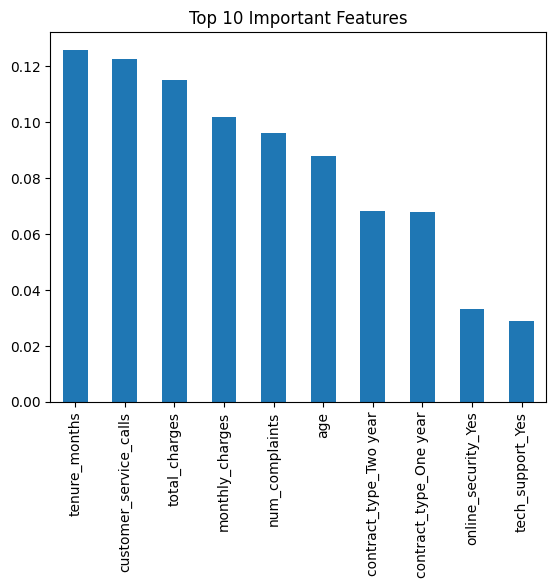

In [25]:
 import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

**ROC Curve**

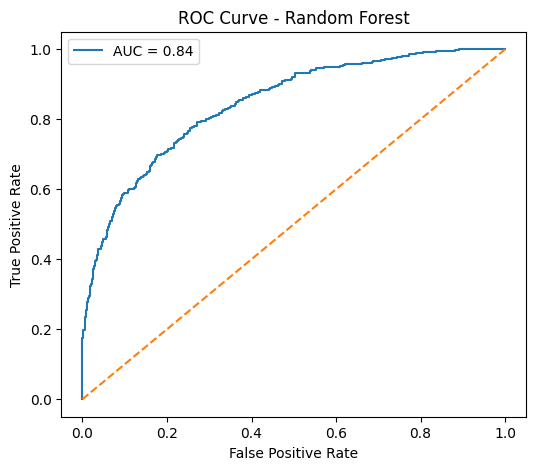

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In this project, we compared Logistic Regression and Random Forest to predict customer churn. Although both models met the required performance standards, **Random Forest** was selected because it better aligns with our business objective.

Logistic Regression achieved a slightly higher ROC-AUC (0.86) and precision (0.83), indicating good overall discrimination and fewer false positives. However, **Random Forest achieved a higher recall (0.83 vs. 0.77), making it more effective at identifying customers who are actually likely to churn**. Since our primary goal is to detect at-risk customers, recall is more critical than precision.

Missing a true churner may result in revenue loss, whereas targeting a non-churner only incurs a minor marketing cost. Additionally, Random Forest can better capture complex relationships between features. For these reasons, Random Forest is selected as the final model.

**Conclusion and Deployment Recommendation**


Based on model performance and business priorities, Random Forest is recommended for deployment in the churn prediction system. It achieves strong predictive accuracy while prioritizing the identification of high-risk customers. By using this model, the company can proactively target customers likely to churn and implement retention strategies to reduce revenue loss. The model meets all defined performance criteria and is suitable for real-world implementation.